# Kalshi BTC Daily Contract Backtesting

This notebook backtests trading strategies on historical Kalshi BTC daily contract data.

## Key Concepts
- **Market Timing**: Kalshi BTC daily markets run 5pm EDT to 5pm EDT next day
- **Settlement**: Based on BTC price at 5pm EDT on the settlement date
- **Signal**: When pdf_estimate exceeds market price by threshold

In [ ]:
# Cell 1: Imports & Configuration
import pandas as pd
import numpy as np
from datetime import datetime, time
import matplotlib.pyplot as plt
import seaborn as sns

# Strategy configuration (user-adjustable)
STRATEGY_CONFIG = {
    'threshold': 5,           # pdf_estimate must exceed price by this amount
    'min_price': 50,           # minimum contract price to consider
    'max_price': 89,           # maximum contract price to consider
    'start_hour': 7,           # trading window start (EST)
    'end_hour': 15,            # trading window end (EST) - 3pm cutoff
    'trade_size': 100,         # dollars per trade
    'require_early_coverage': True,  # Only backtest well-covered days
    'min_coverage_hour': 9,          # Days must have data by this hour
}

# Date range filter (set to None to use all available dates)
DATE_RANGE = {
    'start_date': '2025-01-01',  # Only backtest from this date onwards
    'end_date': None,            # None = up to latest available date
}

print(f"Strategy Config: {STRATEGY_CONFIG}")
print(f"Date Range: {DATE_RANGE}")

Strategy Config: {'threshold': 10, 'min_price': 50, 'max_price': 95, 'start_hour': 7, 'end_hour': 15, 'trade_size': 100, 'require_early_coverage': True, 'min_coverage_hour': 9}
Date Range: {'start_date': '2025-01-01', 'end_date': None}


In [53]:
# Cell 2: Load & Clean Historical Data

def get_settlement_date(timestamp):
    """Convert timestamp to the settlement date it refers to.
    
    Kalshi BTC markets run 5pm-5pm:
    - Before 5pm: settles same day at 5pm
    - After 5pm: settles next day at 5pm
    """
    if timestamp.hour >= 17:  # After 5pm
        return (timestamp + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    else:
        return timestamp.strftime('%Y-%m-%d')


def load_and_clean_data(filepath):
    """Load and clean historical Kalshi data."""
    df = pd.read_csv(filepath)
    
    # Parse timestamps
    df['time'] = pd.to_datetime(df['time'])
    df['hour'] = df['time'].dt.hour
    
    # Critical: Map each row to its settlement date
    df['settlement_date'] = df['time'].apply(get_settlement_date)
    
    # Handle data quality issues
    df = df.dropna(subset=['pdf_estimate', 'current_kalshi_price', 'strike_price'])
    df['pdf_estimate'] = df['pdf_estimate'].clip(0, 100)  # Fix negative values
    df['current_kalshi_price'] = df['current_kalshi_price'].astype(float)
    
    # Remove malformed rows
    df = df[df['strike_price'] > 0]
    df = df[df['contract_type'].isin(['Yes', 'No'])]
    
    return df


def filter_date_range(df, date_range):
    """Filter data to only include specified date range."""
    if date_range.get('start_date'):
        df = df[df['settlement_date'] >= date_range['start_date']]
    if date_range.get('end_date'):
        df = df[df['settlement_date'] <= date_range['end_date']]
    return df


# Load the data
df = load_and_clean_data('kalshi-historical.csv')
print(f"Total rows loaded: {len(df):,}")
print(f"Date range: {df['settlement_date'].min()} to {df['settlement_date'].max()}")
print(f"Unique settlement dates: {df['settlement_date'].nunique()}")
print(f"\nSample data:")
df.head(10)

Total rows loaded: 208,572
Date range: 2025-01-16 to 2026-03-15
Unique settlement dates: 54

Sample data:


,time,currency,event_type,contract_type,strike_price,pdf_estimate,current_kalshi_price,hour,settlement_date
0,2025-01-16 09:15:15,BTC,Daily,No,101250,76.31,90.0,9,2025-01-16
1,2025-01-16 09:15:15,BTC,Daily,Yes,101250,23.69,14.0,9,2025-01-16
2,2025-01-16 09:15:15,BTC,Daily,No,99750,55.79,65.0,9,2025-01-16
3,2025-01-16 09:15:15,BTC,Daily,Yes,99750,44.21,38.0,9,2025-01-16
4,2025-01-16 09:15:15,BTC,Daily,No,99250,48.05,55.0,9,2025-01-16
5,2025-01-16 09:15:15,BTC,Daily,Yes,99250,51.95,50.0,9,2025-01-16
6,2025-01-16 09:15:15,BTC,Daily,No,98750,39.97,42.0,9,2025-01-16
7,2025-01-16 09:15:15,BTC,Daily,Yes,98750,60.03,61.0,9,2025-01-16
8,2025-01-16 09:15:15,BTC,Daily,No,98250,31.24,32.0,9,2025-01-16
9,2025-01-16 09:15:15,BTC,Daily,Yes,98250,68.76,72.0,9,2025-01-16


In [54]:
# Verify settlement date mapping
print("Settlement date mapping verification:")
print("="*50)

# Check samples at different hours
sample_times = df[['time', 'hour', 'settlement_date']].drop_duplicates('time').head(20)
print(sample_times.to_string(index=False))

# Spot check: 9am should settle same day, 9pm should settle next day
morning_samples = df[df['hour'] < 17][['time', 'settlement_date']].drop_duplicates('time').head(3)
evening_samples = df[df['hour'] >= 17][['time', 'settlement_date']].drop_duplicates('time').head(3)

print("\nMorning samples (should settle same day):")
print(morning_samples.to_string(index=False))

if len(evening_samples) > 0:
    print("\nEvening samples (should settle next day):")
    print(evening_samples.to_string(index=False))
else:
    print("\nNo evening samples found (all data is before 5pm)")

Settlement date mapping verification:
               time  hour settlement_date
2025-01-16 09:15:15     9      2025-01-16
2025-01-16 09:16:00     9      2025-01-16
2025-01-16 09:18:00     9      2025-01-16
2025-01-16 09:20:00     9      2025-01-16
2025-01-16 09:22:00     9      2025-01-16
2025-01-16 09:24:00     9      2025-01-16
2025-01-16 09:26:00     9      2025-01-16
2025-01-16 09:28:00     9      2025-01-16
2025-01-16 09:30:00     9      2025-01-16
2025-01-16 09:32:00     9      2025-01-16
2025-01-16 09:34:00     9      2025-01-16
2025-01-16 09:36:00     9      2025-01-16
2025-01-16 09:38:00     9      2025-01-16
2025-01-16 09:40:00     9      2025-01-16
2025-01-16 09:42:00     9      2025-01-16
2025-01-16 09:44:00     9      2025-01-16
2025-01-16 09:46:00     9      2025-01-16
2025-01-16 09:48:00     9      2025-01-16
2025-01-16 09:50:00     9      2025-01-16
2025-01-16 09:52:00     9      2025-01-16

Morning samples (should settle same day):
               time settlement_date
2

In [55]:
# Cell 2.5: Data Coverage Analysis
# For 'first signal' strategies, incomplete coverage is problematic:
# - If data starts at 10am but signals existed at 8am, backtest is biased
# - This cell identifies which days have adequate coverage

def analyze_coverage(df, min_start_hour=9):
    """Analyze data coverage per settlement day.
    
    For 'first signal' strategies, incomplete coverage is problematic:
    - If data starts at 10am but signals existed at 8am, backtest is biased
    - This function identifies which days have adequate coverage
    """
    coverage = df.groupby('settlement_date').agg({
        'hour': ['min', 'max', 'count'],
        'time': ['min', 'max']
    })
    coverage.columns = ['first_hour', 'last_hour', 'observations', 'first_time', 'last_time']
    
    # Flag days with adequate coverage
    coverage['has_early_coverage'] = coverage['first_hour'] <= min_start_hour
    
    return coverage


def filter_well_covered_days(df, coverage, min_start_hour=9):
    """Only keep days where data starts at or before min_start_hour.
    
    This ensures 'first signal' results are not biased by late starts.
    """
    well_covered = coverage[coverage['first_hour'] <= min_start_hour].index
    return df[df['settlement_date'].isin(well_covered)]


# Analyze coverage
coverage = analyze_coverage(df, STRATEGY_CONFIG.get('min_coverage_hour', 9))

print("=== DATA COVERAGE BY SETTLEMENT DATE ===")
print(f"Total days: {len(coverage)}")
print(f"Days with early coverage (first_hour <= {STRATEGY_CONFIG.get('min_coverage_hour', 9)}): {coverage['has_early_coverage'].sum()}")
print(f"Days with late start (first_hour > {STRATEGY_CONFIG.get('min_coverage_hour', 9)}): {(~coverage['has_early_coverage']).sum()}")

print("\n=== COVERAGE SUMMARY ===")
print(coverage[['first_hour', 'last_hour', 'observations', 'has_early_coverage']].to_string())

# Warning about incomplete days
incomplete = coverage[~coverage['has_early_coverage']]
if len(incomplete) > 0:
    print(f"\n WARNING: {len(incomplete)} days have late starts")
    print("These days may have biased 'first signal' results:")
    print(incomplete[['first_hour', 'observations']].to_string())

=== DATA COVERAGE BY SETTLEMENT DATE ===
Total days: 54
Days with early coverage (first_hour <= 9): 39
Days with late start (first_hour > 9): 15

=== COVERAGE SUMMARY ===
                 first_hour  last_hour  observations  has_early_coverage
settlement_date                                                         
2025-01-16                9         16          2362                True
2025-01-17               10         16          1100               False
2025-01-19               16         16            50               False
2025-01-20               12         16          1848               False
2025-01-21                7         16          4034                True
2025-01-23                7         16          3785                True
2025-01-24               13         16           590               False
2025-01-27                9         16          3270                True
2025-01-28                7         16          2604                True
2025-01-29                

In [56]:
# Cell 3: Load Settlements & Add Outcomes

def load_settlements(filepath):
    """Load settlements CSV with columns: settlement_date, highest_yes_strike"""
    settlements = pd.read_csv(filepath)
    return dict(zip(settlements['settlement_date'], settlements['highest_yes_strike']))


def add_settlement_outcomes(df, settlements):
    """Add settled_yes column based on highest YES strike for each day.
    
    If highest_yes_strike = 72500:
    - Yes 72500 -> YES, Yes 72000 -> YES, Yes 73000 -> NO
    - No 72500 -> NO, No 72000 -> NO, No 73000 -> YES
    """
    def determine_outcome(row):
        date = row['settlement_date']
        if date not in settlements:
            return np.nan
        
        highest_yes = settlements[date]
        strike = row['strike_price']
        contract_type = row['contract_type']
        
        if contract_type == 'Yes':
            return 1 if highest_yes >= strike else 0
        else:  # No
            return 1 if highest_yes < strike else 0
    
    df['settled_yes'] = df.apply(determine_outcome, axis=1)
    return df


# Load settlements
try:
    settlements = load_settlements('settlements.csv')
    print(f"Loaded {len(settlements)} settlement records")
    print(f"Settlement dates: {min(settlements.keys())} to {max(settlements.keys())}")
    
    # Add outcomes to data
    df = add_settlement_outcomes(df, settlements)
    
    # Show coverage
    dates_with_settlements = df[df['settled_yes'].notna()]['settlement_date'].nunique()
    total_dates = df['settlement_date'].nunique()
    print(f"\nSettlement coverage: {dates_with_settlements}/{total_dates} dates ({100*dates_with_settlements/total_dates:.1f}%)")
    
except FileNotFoundError:
    print("ERROR: settlements.csv not found!")
    print("\nPlease create settlements.csv with columns: settlement_date, highest_yes_strike")
    print("Example:")
    print("settlement_date,highest_yes_strike")
    print("2026-03-01,82500")
    print("2026-03-03,85000")
    settlements = {}

Loaded 55 settlement records
Settlement dates: 2025-01-16 to 2026-03-15

Settlement coverage: 54/54 dates (100.0%)


In [57]:
# Verify settlement logic with examples
if settlements:
    print("Settlement logic verification:")
    print("="*60)
    
    # Pick a settlement date to verify
    sample_date = list(settlements.keys())[0]
    highest_yes = settlements[sample_date]
    
    print(f"\nFor {sample_date}, highest_yes_strike = {highest_yes}")
    print(f"\nExpected outcomes:")
    print(f"  - Yes {highest_yes} -> YES (strike <= highest_yes)")
    print(f"  - Yes {highest_yes + 500} -> NO (strike > highest_yes)")
    print(f"  - No {highest_yes} -> NO (strike <= highest_yes)")
    print(f"  - No {highest_yes + 500} -> YES (strike > highest_yes)")
    
    # Check actual data
    sample_data = df[df['settlement_date'] == sample_date][['strike_price', 'contract_type', 'settled_yes']].drop_duplicates()
    sample_data = sample_data.sort_values(['strike_price', 'contract_type'])
    
    print(f"\nActual outcomes for {sample_date}:")
    print(sample_data.head(20).to_string(index=False))

Settlement logic verification:

For 2025-01-16, highest_yes_strike = 99750

Expected outcomes:
  - Yes 99750 -> YES (strike <= highest_yes)
  - Yes 100250 -> NO (strike > highest_yes)
  - No 99750 -> NO (strike <= highest_yes)
  - No 100250 -> YES (strike > highest_yes)

Actual outcomes for 2025-01-16:
 strike_price contract_type  settled_yes
        95250            No            0
        95250           Yes            1
        95750            No            0
        95750           Yes            1
        96250            No            0
        96250           Yes            1
        96750            No            0
        96750           Yes            1
        97250            No            0
        97250           Yes            1
        97750            No            0
        97750           Yes            1
        98250            No            0
        98250           Yes            1
        98750            No            0
        98750           Yes            1

In [58]:
# Cell 4: Signal Generation & Deduplication

def generate_signals(df, config):
    """Identify trade entry points based on strategy rules.
    
    Deduplicates by (settlement_date, strike_price, contract_type) -
    only takes FIRST signal per contract per settlement day.
    """
    signals = df.copy()
    
    # Sort by time to ensure we get first signal
    signals = signals.sort_values('time')
    
    # Filter by trading window (EST hours)
    signals = signals[
        (signals['hour'] >= config['start_hour']) &
        (signals['hour'] < config['end_hour'])
    ]
    
    # Filter by price bounds
    signals = signals[
        (signals['current_kalshi_price'] >= config['min_price']) &
        (signals['current_kalshi_price'] <= config['max_price'])
    ]
    
    # Entry condition: pdf_estimate exceeds market price by threshold
    signals = signals[
        signals['pdf_estimate'] > signals['current_kalshi_price'] + config['threshold']
    ]
    
    # Deduplicate: keep only FIRST signal per contract per settlement day
    # This prevents overtrading the same contract
    signals = signals.drop_duplicates(
        subset=['settlement_date', 'strike_price', 'contract_type'],
        keep='first'
    )
    
    return signals


# Apply date range filter first
df_filtered = filter_date_range(df, DATE_RANGE)
print(f"Data after date filter: {len(df_filtered):,} rows")
print(f"Settlement dates: {df_filtered['settlement_date'].nunique()}")

# Apply coverage filter if enabled
if STRATEGY_CONFIG.get('require_early_coverage', False):
    min_hour = STRATEGY_CONFIG.get('min_coverage_hour', 9)
    coverage_filtered = analyze_coverage(df_filtered, min_hour)
    df_filtered = filter_well_covered_days(df_filtered, coverage_filtered, min_hour)
    
    well_covered_count = coverage_filtered['has_early_coverage'].sum()
    total_count = len(coverage_filtered)
    filtered_out = total_count - well_covered_count
    
    print(f"\nCoverage filter applied (require data by hour {min_hour}):")
    print(f"  Well-covered days: {well_covered_count}")
    print(f"  Filtered out (late start): {filtered_out}")
    print(f"  Data after coverage filter: {len(df_filtered):,} rows")
    print(f"  Settlement dates after filter: {df_filtered['settlement_date'].nunique()}")

# Generate signals
signals = generate_signals(df_filtered, STRATEGY_CONFIG)
print(f"\nSignals generated: {len(signals)}")
print(f"Unique settlement dates with signals: {signals['settlement_date'].nunique()}")

# Remove signals without settlement data
signals_with_outcomes = signals[signals['settled_yes'].notna()]
print(f"Signals with settlement data: {len(signals_with_outcomes)}")

if len(signals_with_outcomes) > 0:
    print(f"\nSample signals:")
    display_cols = ['time', 'settlement_date', 'contract_type', 'strike_price', 
                    'pdf_estimate', 'current_kalshi_price', 'settled_yes']
    print(signals_with_outcomes[display_cols].head(10).to_string(index=False))

Data after date filter: 208,572 rows
Settlement dates: 54

Coverage filter applied (require data by hour 9):
  Well-covered days: 39
  Filtered out (late start): 15
  Data after coverage filter: 193,452 rows
  Settlement dates after filter: 39

Signals generated: 91
Unique settlement dates with signals: 29
Signals with settlement data: 91

Sample signals:
               time settlement_date contract_type  strike_price  pdf_estimate  current_kalshi_price  settled_yes
2025-01-16 09:44:00      2025-01-16           Yes         97750         80.68                  64.0            1
2025-01-16 09:44:00      2025-01-16           Yes         98250         65.01                  52.0            1
2025-01-16 09:46:00      2025-01-16           Yes         96750         89.21                  76.0            1
2025-01-16 09:46:00      2025-01-16           Yes         97250         78.65                  66.0            1
2025-01-16 12:48:00      2025-01-16           Yes         99750         63.33

In [59]:
# Cell 5: Backtest Execution

def run_backtest(signals, config):
    """Calculate PnL for each signal."""
    results = signals.copy()
    
    # Remove rows without settlement data
    results = results[results['settled_yes'].notna()]
    
    if len(results) == 0:
        print("No signals with settlement data to backtest!")
        return results
    
    # Calculate profit/loss per contract (in cents)
    # Buy at current_kalshi_price, settle at 100 (yes) or 0 (no)
    results['pnl_cents'] = np.where(
        results['settled_yes'] == 1,
        100 - results['current_kalshi_price'],  # Win: payout - cost
        -results['current_kalshi_price']         # Loss: lose entry cost
    )
    
    # Calculate number of contracts per trade
    results['contracts'] = (config['trade_size'] * 100) // results['current_kalshi_price']
    results['pnl_dollars'] = (results['pnl_cents'] * results['contracts']) / 100
    
    return results


# Run backtest
results = run_backtest(signals, STRATEGY_CONFIG)

if len(results) > 0:
    print(f"Backtest complete: {len(results)} trades")
    print(f"\nSample results:")
    display_cols = ['time', 'settlement_date', 'contract_type', 'strike_price',
                    'current_kalshi_price', 'settled_yes', 'pnl_cents', 'contracts', 'pnl_dollars']
    print(results[display_cols].head(10).to_string(index=False))

Backtest complete: 91 trades

Sample results:
               time settlement_date contract_type  strike_price  current_kalshi_price  settled_yes  pnl_cents  contracts  pnl_dollars
2025-01-16 09:44:00      2025-01-16           Yes         97750                  64.0            1       36.0      156.0        56.16
2025-01-16 09:44:00      2025-01-16           Yes         98250                  52.0            1       48.0      192.0        92.16
2025-01-16 09:46:00      2025-01-16           Yes         96750                  76.0            1       24.0      131.0        31.44
2025-01-16 09:46:00      2025-01-16           Yes         97250                  66.0            1       34.0      151.0        51.34
2025-01-16 12:48:00      2025-01-16           Yes         99750                  53.0            1       47.0      188.0        88.36
2025-01-21 11:10:00      2025-01-21            No        105000                  52.0            0      -52.0      192.0       -99.84
2025-01-21 11:12

In [60]:
# Cell 6: Summary Statistics

def generate_summary(results):
    """Generate backtest summary statistics."""
    if len(results) == 0:
        return None, None
    
    wins = results[results['pnl_cents'] > 0]
    losses = results[results['pnl_cents'] < 0]
    
    summary = {
        'total_trades': len(results),
        'winning_trades': len(wins),
        'losing_trades': len(losses),
        'win_rate': len(wins) / len(results) * 100 if len(results) > 0 else 0,
        'total_pnl': results['pnl_dollars'].sum(),
        'avg_pnl_per_trade': results['pnl_dollars'].mean(),
        'avg_win': wins['pnl_dollars'].mean() if len(wins) > 0 else 0,
        'avg_loss': losses['pnl_dollars'].mean() if len(losses) > 0 else 0,
        'max_win': results['pnl_dollars'].max(),
        'max_loss': results['pnl_dollars'].min(),
        'sharpe_approx': results['pnl_dollars'].mean() / results['pnl_dollars'].std() if results['pnl_dollars'].std() > 0 else 0,
    }
    
    # Per-settlement-day breakdown
    daily = results.groupby('settlement_date').agg({
        'pnl_dollars': ['sum', 'count'],
        'settled_yes': 'mean'
    }).round(2)
    daily.columns = ['daily_pnl', 'num_trades', 'win_rate']
    
    return summary, daily


if len(results) > 0:
    summary, daily = generate_summary(results)
    
    print("=" * 50)
    print("BACKTEST SUMMARY")
    print("=" * 50)
    print(f"\nStrategy Configuration:")
    for k, v in STRATEGY_CONFIG.items():
        print(f"  {k}: {v}")
    
    print(f"\nDate Range: {DATE_RANGE['start_date']} to {DATE_RANGE['end_date'] or 'latest'}")
    
    print(f"\nPerformance Metrics:")
    print(f"  Total Trades: {summary['total_trades']}")
    print(f"  Winning Trades: {summary['winning_trades']}")
    print(f"  Losing Trades: {summary['losing_trades']}")
    print(f"  Win Rate: {summary['win_rate']:.1f}%")
    print(f"\n  Total P&L: ${summary['total_pnl']:.2f}")
    print(f"  Avg P&L per Trade: ${summary['avg_pnl_per_trade']:.2f}")
    print(f"  Avg Win: ${summary['avg_win']:.2f}")
    print(f"  Avg Loss: ${summary['avg_loss']:.2f}")
    print(f"  Max Win: ${summary['max_win']:.2f}")
    print(f"  Max Loss: ${summary['max_loss']:.2f}")
    print(f"\n  Sharpe (approx): {summary['sharpe_approx']:.3f}")
    
    print(f"\n" + "=" * 50)
    print("DAILY BREAKDOWN")
    print("=" * 50)
    print(daily.to_string())
else:
    print("No trades to summarize. Check your settlements.csv file.")

BACKTEST SUMMARY

Strategy Configuration:
  threshold: 10
  min_price: 50
  max_price: 95
  start_hour: 7
  end_hour: 15
  trade_size: 100
  require_early_coverage: True
  min_coverage_hour: 9

Date Range: 2025-01-01 to latest

Performance Metrics:
  Total Trades: 91
  Winning Trades: 50
  Losing Trades: 41
  Win Rate: 54.9%

  Total P&L: $-452.08
  Avg P&L per Trade: $-4.97
  Avg Win: $72.75
  Avg Loss: $-99.74
  Max Win: $100.00
  Max Loss: $-100.00

  Sharpe (approx): -0.056

DAILY BREAKDOWN
                 daily_pnl  num_trades  win_rate
settlement_date                                 
2025-01-16          319.46           5      1.00
2025-01-21         -199.59           2      0.00
2025-01-23          -39.73           5      0.60
2025-01-27          100.00           1      1.00
2025-01-28         -199.35           2      0.00
2025-01-29          171.29           2      1.00
2025-01-30          -21.36           2      0.50
2025-02-03         -405.92           6      0.17
2025-02-12

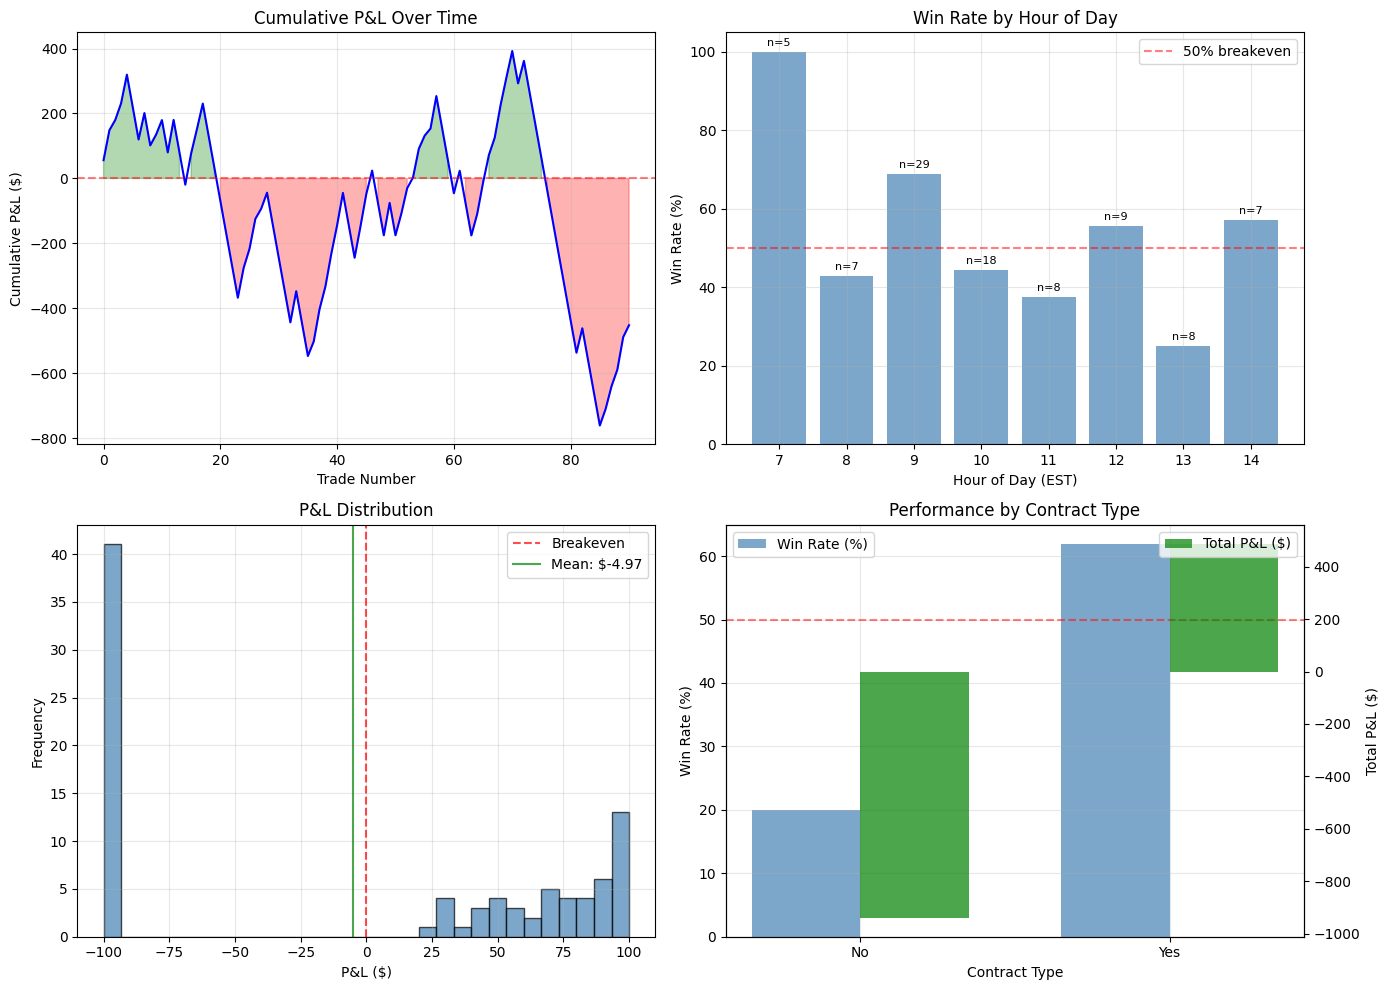


Contract Type Statistics:
  No: 15 trades, 20.0% win rate, $-940.29 total P&L
  Yes: 76 trades, 61.8% win rate, $488.21 total P&L


In [61]:
# Cell 7: Visualization

if len(results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Cumulative PnL over time
    ax1 = axes[0, 0]
    results_sorted = results.sort_values('time')
    results_sorted['cumulative_pnl'] = results_sorted['pnl_dollars'].cumsum()
    ax1.plot(range(len(results_sorted)), results_sorted['cumulative_pnl'], 'b-', linewidth=1.5)
    ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    ax1.fill_between(range(len(results_sorted)), results_sorted['cumulative_pnl'], 
                     where=results_sorted['cumulative_pnl'] >= 0, alpha=0.3, color='green')
    ax1.fill_between(range(len(results_sorted)), results_sorted['cumulative_pnl'], 
                     where=results_sorted['cumulative_pnl'] < 0, alpha=0.3, color='red')
    ax1.set_xlabel('Trade Number')
    ax1.set_ylabel('Cumulative P&L ($)')
    ax1.set_title('Cumulative P&L Over Time')
    ax1.grid(True, alpha=0.3)
    
    # 2. Win rate by hour of day
    ax2 = axes[0, 1]
    hourly_stats = results.groupby('hour').agg({
        'settled_yes': ['mean', 'count']
    })
    hourly_stats.columns = ['win_rate', 'count']
    hourly_stats['win_rate'] = hourly_stats['win_rate'] * 100
    
    bars = ax2.bar(hourly_stats.index, hourly_stats['win_rate'], color='steelblue', alpha=0.7)
    ax2.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='50% breakeven')
    ax2.set_xlabel('Hour of Day (EST)')
    ax2.set_ylabel('Win Rate (%)')
    ax2.set_title('Win Rate by Hour of Day')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Add trade counts as text
    for bar, count in zip(bars, hourly_stats['count']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'n={int(count)}', ha='center', va='bottom', fontsize=8)
    
    # 3. PnL distribution histogram
    ax3 = axes[1, 0]
    ax3.hist(results['pnl_dollars'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax3.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='Breakeven')
    ax3.axvline(x=results['pnl_dollars'].mean(), color='g', linestyle='-', alpha=0.7, 
                label=f'Mean: ${results["pnl_dollars"].mean():.2f}')
    ax3.set_xlabel('P&L ($)')
    ax3.set_ylabel('Frequency')
    ax3.set_title('P&L Distribution')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Win rate by contract type
    ax4 = axes[1, 1]
    contract_stats = results.groupby('contract_type').agg({
        'settled_yes': ['mean', 'count'],
        'pnl_dollars': 'sum'
    })
    contract_stats.columns = ['win_rate', 'count', 'total_pnl']
    contract_stats['win_rate'] = contract_stats['win_rate'] * 100
    
    x = range(len(contract_stats))
    width = 0.35
    bars1 = ax4.bar([i - width/2 for i in x], contract_stats['win_rate'], width, 
                    label='Win Rate (%)', color='steelblue', alpha=0.7)
    ax4.set_ylabel('Win Rate (%)')
    ax4.set_xlabel('Contract Type')
    ax4.set_title('Performance by Contract Type')
    ax4.set_xticks(x)
    ax4.set_xticklabels(contract_stats.index)
    ax4.axhline(y=50, color='r', linestyle='--', alpha=0.5)
    ax4.legend(loc='upper left')
    ax4.grid(True, alpha=0.3)
    
    # Add secondary y-axis for total PnL
    ax4b = ax4.twinx()
    bars2 = ax4b.bar([i + width/2 for i in x], contract_stats['total_pnl'], width,
                     label='Total P&L ($)', color='green', alpha=0.7)
    ax4b.set_ylabel('Total P&L ($)')
    ax4b.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # Print contract type stats
    print("\nContract Type Statistics:")
    for contract_type in contract_stats.index:
        stats = contract_stats.loc[contract_type]
        print(f"  {contract_type}: {int(stats['count'])} trades, "
              f"{stats['win_rate']:.1f}% win rate, "
              f"${stats['total_pnl']:.2f} total P&L")
else:
    print("No results to visualize.")

Parameter Sensitivity Analysis
(Coverage filter enabled: days must have data by hour 9)

Threshold Sensitivity:
 threshold  trades  win_rate  total_pnl    avg_pnl    sharpe
         5     219 63.013699     577.77   2.638219  0.032389
        10      91 54.945055    -452.08  -4.967912 -0.056435
        15      29 41.379310    -891.95 -30.756897 -0.362261
        20      14 50.000000    -154.02 -11.001429 -0.118084
        25       4 50.000000     -87.12 -21.780000 -0.238772


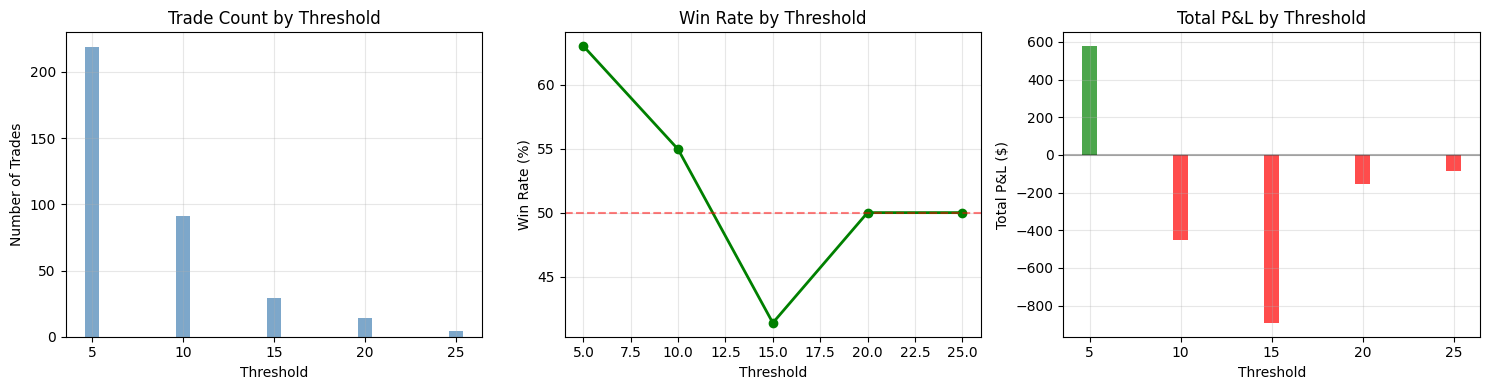

In [62]:
# Cell 8: Parameter Sensitivity Analysis

def run_sensitivity_analysis(df, base_config, date_range):
    """Test different parameter values and compare results."""
    
    # Apply date filter
    df_filtered = filter_date_range(df, date_range)
    
    # Apply coverage filter if enabled
    if base_config.get('require_early_coverage', False):
        min_hour = base_config.get('min_coverage_hour', 9)
        coverage_filtered = analyze_coverage(df_filtered, min_hour)
        df_filtered = filter_well_covered_days(df_filtered, coverage_filtered, min_hour)
    
    # Test different thresholds
    thresholds = [5, 10, 15, 20, 25]
    threshold_results = []
    
    for threshold in thresholds:
        config = base_config.copy()
        config['threshold'] = threshold
        
        signals = generate_signals(df_filtered, config)
        results = run_backtest(signals, config)
        
        if len(results) > 0:
            wins = (results['pnl_cents'] > 0).sum()
            threshold_results.append({
                'threshold': threshold,
                'trades': len(results),
                'win_rate': wins / len(results) * 100,
                'total_pnl': results['pnl_dollars'].sum(),
                'avg_pnl': results['pnl_dollars'].mean(),
                'sharpe': results['pnl_dollars'].mean() / results['pnl_dollars'].std() if results['pnl_dollars'].std() > 0 else 0
            })
        else:
            threshold_results.append({
                'threshold': threshold,
                'trades': 0,
                'win_rate': 0,
                'total_pnl': 0,
                'avg_pnl': 0,
                'sharpe': 0
            })
    
    return pd.DataFrame(threshold_results)


if settlements:
    print("Parameter Sensitivity Analysis")
    print("=" * 70)
    if STRATEGY_CONFIG.get('require_early_coverage', False):
        print(f"(Coverage filter enabled: days must have data by hour {STRATEGY_CONFIG.get('min_coverage_hour', 9)})")
    
    sensitivity_df = run_sensitivity_analysis(df, STRATEGY_CONFIG, DATE_RANGE)
    
    print("\nThreshold Sensitivity:")
    print(sensitivity_df.to_string(index=False))
    
    # Visualize
    if sensitivity_df['trades'].sum() > 0:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # Trades vs Threshold
        axes[0].bar(sensitivity_df['threshold'], sensitivity_df['trades'], color='steelblue', alpha=0.7)
        axes[0].set_xlabel('Threshold')
        axes[0].set_ylabel('Number of Trades')
        axes[0].set_title('Trade Count by Threshold')
        axes[0].grid(True, alpha=0.3)
        
        # Win Rate vs Threshold
        axes[1].plot(sensitivity_df['threshold'], sensitivity_df['win_rate'], 'o-', color='green', linewidth=2)
        axes[1].axhline(y=50, color='r', linestyle='--', alpha=0.5)
        axes[1].set_xlabel('Threshold')
        axes[1].set_ylabel('Win Rate (%)')
        axes[1].set_title('Win Rate by Threshold')
        axes[1].grid(True, alpha=0.3)
        
        # Total PnL vs Threshold
        colors = ['green' if x >= 0 else 'red' for x in sensitivity_df['total_pnl']]
        axes[2].bar(sensitivity_df['threshold'], sensitivity_df['total_pnl'], color=colors, alpha=0.7)
        axes[2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
        axes[2].set_xlabel('Threshold')
        axes[2].set_ylabel('Total P&L ($)')
        axes[2].set_title('Total P&L by Threshold')
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("Cannot run sensitivity analysis without settlements data.")

In [63]:
# Cell 9: Trading Window Analysis

def analyze_trading_windows(df, base_config, date_range):
    """Compare different trading windows."""
    
    df_filtered = filter_date_range(df, date_range)
    
    # Apply coverage filter if enabled
    if base_config.get('require_early_coverage', False):
        min_hour = base_config.get('min_coverage_hour', 9)
        coverage_filtered = analyze_coverage(df_filtered, min_hour)
        df_filtered = filter_well_covered_days(df_filtered, coverage_filtered, min_hour)
    
    windows = [
        (7, 11, 'Morning (7am-11am)'),
        (11, 15, 'Midday (11am-3pm)'),
        (7, 15, 'Full Day (7am-3pm)'),
        (9, 14, 'Core Hours (9am-2pm)'),
    ]
    
    window_results = []
    
    for start, end, name in windows:
        config = base_config.copy()
        config['start_hour'] = start
        config['end_hour'] = end
        
        signals = generate_signals(df_filtered, config)
        results = run_backtest(signals, config)
        
        if len(results) > 0:
            wins = (results['pnl_cents'] > 0).sum()
            window_results.append({
                'window': name,
                'trades': len(results),
                'win_rate': wins / len(results) * 100,
                'total_pnl': results['pnl_dollars'].sum(),
                'avg_pnl': results['pnl_dollars'].mean(),
            })
        else:
            window_results.append({
                'window': name,
                'trades': 0,
                'win_rate': 0,
                'total_pnl': 0,
                'avg_pnl': 0,
            })
    
    return pd.DataFrame(window_results)


if settlements:
    print("Trading Window Analysis")
    print("=" * 70)
    if STRATEGY_CONFIG.get('require_early_coverage', False):
        print(f"(Coverage filter enabled: days must have data by hour {STRATEGY_CONFIG.get('min_coverage_hour', 9)})")
    
    window_df = analyze_trading_windows(df, STRATEGY_CONFIG, DATE_RANGE)
    print(window_df.to_string(index=False))
else:
    print("Cannot run window analysis without settlements data.")

Trading Window Analysis
(Coverage filter enabled: days must have data by hour 9)
              window  trades  win_rate  total_pnl    avg_pnl
  Morning (7am-11am)      59 61.016949     187.49   3.177797
   Midday (11am-3pm)      44 47.727273    -613.39 -13.940682
  Full Day (7am-3pm)      91 54.945055    -452.08  -4.967912
Core Hours (9am-2pm)      76 52.631579    -688.92  -9.064737


In [64]:
# Cell 10: Export Results

if len(results) > 0:
    # Export detailed trade log
    export_cols = ['time', 'settlement_date', 'contract_type', 'strike_price',
                   'pdf_estimate', 'current_kalshi_price', 'settled_yes',
                   'pnl_cents', 'contracts', 'pnl_dollars']
    
    results[export_cols].to_csv('backtest_results.csv', index=False)
    print("Trade log exported to backtest_results.csv")
    
    # Export summary
    with open('backtest_summary.txt', 'w') as f:
        f.write("BACKTEST SUMMARY\n")
        f.write("=" * 50 + "\n\n")
        f.write(f"Strategy Configuration:\n")
        for k, v in STRATEGY_CONFIG.items():
            f.write(f"  {k}: {v}\n")
        f.write(f"\nDate Range: {DATE_RANGE['start_date']} to {DATE_RANGE['end_date'] or 'latest'}\n")
        f.write(f"\nPerformance Metrics:\n")
        for k, v in summary.items():
            if isinstance(v, float):
                f.write(f"  {k}: {v:.2f}\n")
            else:
                f.write(f"  {k}: {v}\n")
    
    print("Summary exported to backtest_summary.txt")
else:
    print("No results to export.")

Trade log exported to backtest_results.csv
Summary exported to backtest_summary.txt
